# Synthetic Probe Analysis

Train logistic-regression probes on JudgementLM internal representations collected
from the **synthetic probe dataset** (`data/{dataset}/probe_dataset.json`),
then evaluate on **real extraction data** from papers not present in the synthetic set.

**Labels**
- Training: `label` field in the synthetic dataset (`"valid"` / `"invalid"`)
- Test: controlled by `LABEL_MODE` — either matching status only, or the union of matching status and majority-vote judge

---

**Part I — Attention Head Probe**  
Score every (layer, head) pair on synthetic 5-fold CV, select the best head,
train a final probe on the synthetic training split, Platt-calibrate on the
synthetic calibration split, and evaluate on the real test set.

**Part II — Layer Output Probe**  
Score every layer's full residual-stream vector on synthetic 5-fold CV, select the
best layer, and repeat the same train → calibrate → test protocol on the same splits.

---

**Metrics reported:** AUROC · F1 · ECE · Brier Score (BS) · Brier Skill Score (BSS)

> **Class imbalance note.** The real test set is skewed toward invalid extractions.
> All CV probes use `class_weight='balanced'` during head/layer selection to prevent
> the majority class from dominating selection. Brier Skill Score
> (BSS = 1 − BS / BS_ref, where BS_ref = p̄(1−p̄)) normalises against a naïve
> constant-prediction baseline, making it more informative than raw BS under imbalance.

In [ ]:
import sys
from pathlib import Path
%load_ext autoreload
%autoreload 2

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from analysis.loaders import (
    load_synthetic_activations, load_synthetic_layer_outputs, load_synthetic_responses,
    load_activations, load_layer_outputs, load_combined_judgements,
    load_extraction, load_ground_truth, cached_match,
)
from analysis.plots import calibration_curve, probability_distribution
from scholarlm.utils.probe import (
    grouped_kfold_split, grouped_holdout_split,
)
from scholarlm.utils.calibration import reliability_diagram_data
from scholarlm.utils.unit_conversion import apply_unit_conversion
from experiments.run_extraction import load_dataset_config
import paths

# Publication style
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.title_fontsize": 9,
    "axes.linewidth": 0.6,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.major.size": 3, "ytick.major.size": 3,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "lines.linewidth": 1.2, "lines.markersize": 4,
    "legend.frameon": False,
    "figure.dpi": 150, "savefig.dpi": 300,
    "savefig.format": "pdf", "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

FIGURES_DIR = "../figures/synthetic_probe/"
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

In [ ]:
# ── Parameters ───────────────────────────────────────────────────────────────
DATASET          = 'pond'
JUDGE_MODEL      = 'llama-3.1-8b'   # must match judge used for both synthetic and real runs
JUDGE_DATE_SYN   = None              # auto-detect latest synthetic probe run

# Real extraction run to use for test set
EXTRACTION_MODEL = 'gemma-3-27b'
EXTRACTION_DATE  = '2026_04_25'
JUDGE_DATE_REAL  = '2026_04_27'

TOP_K   = 5    # heads for greedy selection
N_FOLDS = 5

# Label definition for the real test set:
#   'matching' — positive iff the extraction matches a ground-truth row
#   'union'    — positive if matching OR majority-vote judge says valid
LABEL_MODE = 'matching'

## Load Synthetic Data

In [ ]:
syn_activations = load_synthetic_activations(DATASET, JUDGE_MODEL, JUDGE_DATE_SYN)
syn_responses   = load_synthetic_responses(DATASET, JUDGE_MODEL, JUDGE_DATE_SYN)
syn_df          = pd.DataFrame(syn_responses)

syn_measurement_ids = syn_df['measurement_id'].tolist()
syn_labels          = (syn_df['label'] == 'valid').to_numpy(dtype=bool)
syn_groups          = syn_df['document_id'].to_numpy()

print(f'Synthetic activations : {len(syn_activations.files)} entries')
print(f'Synthetic records     : {len(syn_df)}')
print(f'  Valid   : {syn_labels.sum()} ({syn_labels.mean():.1%})')
print(f'  Invalid : {(~syn_labels).sum()} ({(~syn_labels).mean():.1%})')
print(f'Unique papers in synthetic set : {syn_df["document_id"].nunique()}')
print()
print('Modification types:')
print(syn_df['modification_type'].value_counts(dropna=False))

In [ ]:
# Group-aware 80/20 train/calibration split within the synthetic set.
# No paper (document_id) appears in both splits.
syn_train_idx, syn_cal_idx, _ = grouped_holdout_split(
    syn_groups, train_frac=0.80, cal_frac=0.20, random_state=42
)
syn_cv_idx    = np.concatenate([syn_train_idx, syn_cal_idx])
syn_labels_cv = syn_labels[syn_cv_idx]
syn_groups_cv = syn_groups[syn_cv_idx]
kfold_cv = list(grouped_kfold_split(syn_groups_cv, n_splits=N_FOLDS, random_state=42))

print(f'Synthetic split (total n={len(syn_labels)}):')
print(f'  Train : {len(syn_train_idx):4d} ({len(syn_train_idx)/len(syn_labels):.1%})  pos={syn_labels[syn_train_idx].mean():.2%}')
print(f'  Cal   : {len(syn_cal_idx):4d} ({len(syn_cal_idx)/len(syn_labels):.1%})  pos={syn_labels[syn_cal_idx].mean():.2%}')

## Load Real Data for Testing

In [ ]:
real_activations = load_activations(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE, JUDGE_MODEL, JUDGE_DATE_REAL)
real_judgements  = load_combined_judgements(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE)
real_df          = pd.DataFrame(real_judgements)

config          = load_dataset_config(DATASET)
records         = load_extraction(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE)
extraction_df   = pd.DataFrame(records)
extraction_df   = apply_unit_conversion(extraction_df, config.unit_conversion_table)
ground_truth_df = load_ground_truth(config)

print(f'Real activations : {len(real_activations.files)} entries')
print(f'Real judgements  : {len(real_df)} records')
print(f'Ground truth     : {len(ground_truth_df)} records')

In [ ]:
if 'pond' in DATASET:
    STRICT_MATCHING = {'document_id': 'document_id', 'attribute': 'attribute', 'value': 'converted_value', 'units': 'units'}
    FUZZY_MATCHING  = {'name': 'name', 'location': 'location', 'ecosystem': 'ecosystem'}
elif 'nfix' in DATASET:
    extraction_df['attribute'] = extraction_df['attribute'].map({'nfix_rate_areal': 'nfix_rate', 'nfix_rate_volumetric': 'nfix_rate', 'nfix_rate_mass': 'nfix_rate', 'nfix_rate': 'nfix_rate'})
    extraction_df["units"] = extraction_df["units"].apply(nfix_clean_unit)
    STRICT_MATCHING = {'document_id': 'document_id', 'attribute': 'attribute', 'value': 'converted_value', 'units': 'units'}
    FUZZY_MATCHING  = {"name": "name", "site_type": "site_type"}
else:
    raise ValueError("Dataset not recognized.")

cache_path = paths.extraction(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE) / 'match_cache.pkl'

matching, edges, weights = cached_match(
    ground_truth_df, extraction_df,
    strict_matching=STRICT_MATCHING,
    fuzzy_matching=FUZZY_MATCHING,
    fuzzy_threshold=0.0,
    cache_path=cache_path,
)

THRESHOLD = 1/3
ex_edge_exists = np.zeros(len(extraction_df), dtype=bool)
for i, (gt_idx, ex_idx) in enumerate(edges):
    if weights[i] > THRESHOLD:
        ex_edge_exists[ex_idx] = True

if LABEL_MODE == 'union':
    jlabels     = real_df['judgement_combined'].to_numpy(dtype=bool)
    real_labels = jlabels | ex_edge_exists
    print(f'Label mode: union (matching OR judge)  pos_rate={real_labels.mean():.2%}')
else:
    real_labels = ex_edge_exists
    print(f'Label mode: matching only  pos_rate={real_labels.mean():.2%}')

In [ ]:
# Filter real data to papers NOT in the synthetic set.
# Both syn_df['document_id'] and real_df['document_id'] are string paper codes.
syn_document_ids  = set(syn_df['document_id'].tolist())
real_test_mask    = ~real_df['document_id'].isin(syn_document_ids)
real_test_idx     = np.where(real_test_mask.to_numpy())[0]
real_test_mids    = real_df['measurement_id'].iloc[real_test_idx].tolist()
real_test_labels  = real_labels[real_test_idx]
real_test_jprobs  = real_df[f'judgement_p_true_{JUDGE_MODEL}'].iloc[real_test_idx].to_numpy()

print(f'Papers in synthetic set             : {len(syn_document_ids)}')
print(f'Papers in real data                 : {real_df["document_id"].nunique()}')
print(f'Papers in real EXCLUDING synthetic  : {real_df.iloc[real_test_idx]["document_id"].nunique()}')
print(f'Real test records                   : {len(real_test_idx)}')
print(f'  Positive rate                     : {real_test_labels.mean():.2%}')

---
## Part I — Attention Head Probe

Select the single best (layer, head) pair by F1 on synthetic 5-fold CV.
Train the final probe on the synthetic training split, Platt-calibrate on the
synthetic calibration split, and evaluate on real data (papers excluded from training).

## Build Head Feature Matrices

In [ ]:
_arr0 = np.array(syn_activations[str(syn_measurement_ids[0])], dtype=np.float32)
n_layers, n_heads, head_dim = _arr0.shape
print(f'Activation shape : n_layers={n_layers}, n_heads={n_heads}, head_dim={head_dim}')
print(f'Total heads      : {n_layers * n_heads}')

print('\nLoading synthetic activations into memory...')
_all_syn = {
    str(mid): np.array(syn_activations[str(mid)], dtype=np.float32)
    for mid in syn_measurement_ids
}
print('Building per-head feature matrices (synthetic)...')
head_datasets_syn: dict[tuple[int, int], np.ndarray] = {}
for l in range(n_layers):
    for h in range(n_heads):
        head_datasets_syn[(l, h)] = np.stack(
            [_all_syn[str(mid)][l, h, :] for mid in syn_measurement_ids], axis=0
        )
del _all_syn
print(f'  Synthetic head matrix shape: {head_datasets_syn[(0, 0)].shape}')

print(f'\nLoading real activations for test set ({len(real_test_mids)} records)...')
_all_real = {
    str(mid): np.array(real_activations[str(mid)], dtype=np.float32)
    for mid in real_test_mids
}
print('Building per-head feature matrices (real test)...')
head_datasets_real: dict[tuple[int, int], np.ndarray] = {}
for l in range(n_layers):
    for h in range(n_heads):
        head_datasets_real[(l, h)] = np.stack(
            [_all_real[str(mid)][l, h, :] for mid in real_test_mids], axis=0
        )
del _all_real
print(f'  Real test head matrix shape : {head_datasets_real[(0, 0)].shape}')

## Baseline: Raw Judge Performance on Real Test Set

In [ ]:
def _probe_metrics(probs, y_true, label, threshold=0.5):
    preds = probs > threshold
    tp  = int(( preds &  y_true).sum())
    tn  = int((~preds & ~y_true).sum())
    fp  = int(( preds & ~y_true).sum())
    fn  = int((~preds &  y_true).sum())
    n   = len(y_true)
    acc   = (tp + tn) / n
    prec  = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec   = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else float('nan')
    auroc = roc_auc_score(y_true, probs) if y_true.sum() > 0 and (~y_true).sum() > 0 else float('nan')
    ece   = reliability_diagram_data(probs, y_true)['ece']
    bs    = float(brier_score_loss(y_true, probs))
    p_pos = float(y_true.mean())
    bs_ref = p_pos * (1.0 - p_pos)
    bss   = 1.0 - bs / bs_ref if bs_ref > 0 else float('nan')
    print(f'{label}:')
    print(f'  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}')
    print(f'  AUROC={auroc:.4f}  ECE={ece:.4f}  BS={bs:.4f}  BSS={bss:.4f}')
    print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}  n={n}  pos={p_pos:.2%}')
    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1,
            'auroc': auroc, 'ece': ece, 'bs': bs, 'bss': bss}


def cv_score(probe, X, y, kfold_cv):
    fold_accs, fold_aurocs, fold_f1s, fold_bs = [], [], [], []
    fold_test_idx, fold_probs_list = [], []
    for train_idx, test_idx in kfold_cv:
        probe.fit(X[train_idx], y[train_idx])
        y_pred = probe.predict(X[test_idx])
        y_true = y[test_idx]
        probs  = probe.predict_proba(X[test_idx])[:, 1]
        fold_accs.append(float((y_pred == y_true).mean()))
        auroc = roc_auc_score(y_true, probs) if y_true.sum() > 0 and (~y_true).sum() > 0 else float('nan')
        fold_aurocs.append(auroc)
        tp   = int(( y_pred &  y_true).sum())
        fp   = int(( y_pred & ~y_true).sum())
        fn   = int((~y_pred &  y_true).sum())
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fold_f1s.append(2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0)
        fold_bs.append(float(brier_score_loss(y_true, probs)))
        fold_test_idx.extend(test_idx)
        fold_probs_list.append(probs)
    oof_probs  = np.empty(len(y))
    sort_order = np.argsort(fold_test_idx)
    oof_probs[np.array(fold_test_idx)[sort_order]] = np.concatenate(fold_probs_list)[sort_order]
    return (
        float(np.mean(fold_accs)),   list(fold_accs),
        float(np.nanmean(fold_aurocs)), list(fold_aurocs),
        float(np.mean(fold_f1s)),    list(fold_f1s),
        float(np.mean(fold_bs)),     list(fold_bs),
        oof_probs,
    )


judge_preds = real_df.iloc[real_test_idx][f'judgement_{JUDGE_MODEL}'].astype(bool).values
_probe_metrics(real_test_jprobs, real_test_labels, 'Raw judge (real test set)')

## Head Selection (CV on Synthetic Data)

In [ ]:
probe_template = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0, class_weight='balanced', solver='lbfgs',
        max_iter=1000, random_state=42,
    ))
])

head_scores_acc   = np.zeros((n_layers, n_heads))
head_scores_auroc = np.zeros((n_layers, n_heads))
head_scores_f1    = np.zeros((n_layers, n_heads))
head_oof_probs    = {}

print(f'Scoring {n_layers * n_heads} heads on synthetic CV pool (n={len(syn_cv_idx)})...')
for l in range(n_layers):
    for h in range(n_heads):
        X_cv = head_datasets_syn[(l, h)][syn_cv_idx]
        (mean_acc, _,
         mean_auroc, _,
         mean_f1, _,
         mean_bs, _,
         oof_probs) = cv_score(probe_template, X_cv, syn_labels_cv, kfold_cv)
        head_scores_acc[l, h]   = mean_acc
        head_scores_auroc[l, h] = mean_auroc
        head_scores_f1[l, h]    = mean_f1
        head_oof_probs[(l, h)]  = oof_probs
    if (l + 1) % 8 == 0:
        print(f'  Layer {l + 1}/{n_layers} done')

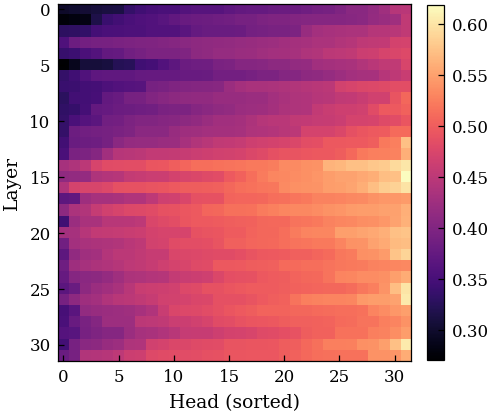

In [57]:
score_mat = head_scores_f1
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
im = ax.imshow(np.sort(score_mat, axis=1), cmap='magma', aspect='auto')
ax.set_xlabel('Head (sorted)')
ax.set_ylabel('Layer')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
#fig.savefig(FIGURES_DIR + f'synprobe_heatmap_{DATASET}_j-{JUDGE_MODEL}.pdf', bbox_inches='tight')

In [50]:
best_l, best_h = np.unravel_index(score_mat.argmax(), score_mat.shape)
print(f'Best single head: layer={best_l}, head={best_h}')
print(f'  AUROC={head_scores_auroc[best_l, best_h]:.4f}  '
      f'F1={head_scores_f1[best_l, best_h]:.4f}  '
      f'Acc={head_scores_acc[best_l, best_h]:.4f}')

k = 1
flat_indices = np.argsort(score_mat.flatten())[-k:][::-1]
top_k_heads  = [np.unravel_index(idx, score_mat.shape) for idx in flat_indices]

print(f'\nTop {k} heads by CV F1:')
for i, (bl, bh) in enumerate(top_k_heads):
    print(f'  {i+1}. layer={bl}, head={bh}  '
          f'AUROC={head_scores_auroc[bl, bh]:.4f}  '
          f'F1={head_scores_f1[bl, bh]:.4f}')

Best single head: layer=15, head=14
  AUROC=0.7909  F1=0.6194  Acc=0.6983

Top 1 heads by CV F1:
  1. layer=15, head=14  AUROC=0.7909  F1=0.6194


In [ ]:
# F1 by layer: max and mean across all heads at each layer
layer_max_f1  = head_scores_f1.max(axis=1)
layer_mean_f1 = head_scores_f1.mean(axis=1)
layers        = np.arange(n_layers)

fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.plot(layers, layer_max_f1,  'o-', color='#3984e0', ms=3, label='Max across heads')
ax.plot(layers, layer_mean_f1, 's--', color='#888888', ms=2.5, lw=0.9, label='Mean across heads')
ax.axvline(best_l, color='#e07b39', lw=1.0, ls=':', label=f'Selected head (L{best_l}H{best_h})')
ax.set_xlabel('Layer')
ax.set_ylabel('CV F1')
ax.set_title(f'Attention head probe — CV F1 by layer ({DATASET}, {JUDGE_MODEL})')
ax.legend(fontsize=7)
ax.set_xlim(-0.5, n_layers - 0.5)
fig.tight_layout()
#fig.savefig(FIGURES_DIR + f'synprobe_head_f1_by_layer_{DATASET}_j-{JUDGE_MODEL}.pdf', bbox_inches='tight')

## Train on Synthetic, Test on Real

Train the final probe on the synthetic training set, Platt-calibrate on the
synthetic calibration set, then evaluate on real extraction data from papers
not present in the synthetic dataset.

In [58]:
def _build_syn(idx_set, heads):
    return np.concatenate([head_datasets_syn[lh][idx_set] for lh in heads], axis=1)

def _build_real(heads):
    return np.concatenate([head_datasets_real[lh] for lh in heads], axis=1)

X_train = _build_syn(syn_train_idx, top_k_heads)
X_cal   = _build_syn(syn_cal_idx,   top_k_heads)
X_real  = _build_real(top_k_heads)

y_train = syn_labels[syn_train_idx]
y_cal   = syn_labels[syn_cal_idx]
y_real  = real_test_labels

# Train final probe on synthetic training set
final_probe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0, class_weight=None, solver='lbfgs',
        max_iter=1000, random_state=42,
    ))
]).fit(X_train, y_train)

# Platt scaling on synthetic calibration set
raw_cal  = final_probe.predict_proba(X_cal)[:, 1].reshape(-1, 1)
platt    = LogisticRegression(C=1e6, solver='lbfgs', max_iter=1000).fit(raw_cal, y_cal)

# Probabilities on real test set
raw_real = final_probe.predict_proba(X_real)[:, 1]
cal_real = platt.predict_proba(raw_real.reshape(-1, 1))[:, 1]

# Also Platt-calibrate the judge probabilities using synthetic cal set
raw_judge_cal = real_df[f'judgement_p_true_{JUDGE_MODEL}'].iloc[
    real_df['document_id'].isin(syn_df['document_id']).pipe(lambda m: real_df.index[~m])
    if False else list(real_test_idx)
].to_numpy().reshape(-1, 1)

head_labels = [f'L{l}H{h}' for l, h in top_k_heads]
print(f'=== {TOP_K}-head probe {head_labels} — REAL test set ===\n')
_probe_metrics(real_test_jprobs, y_real, 'Judge NTP probability (uncalibrated)')
print()
_probe_metrics(raw_real, y_real, 'Probe (uncalibrated)')
print()
_probe_metrics(cal_real, y_real, 'Probe (Platt-calibrated on synthetic cal set)')

=== 5-head probe ['L15H14'] — REAL test set ===

Judge NTP probability (uncalibrated):
  Accuracy=0.5203  Precision=0.4115  Recall=0.9176  F1=0.5682
  AUROC=0.6612  ECE=0.3371
  TP=1592  TN=1033  FP=2277  FN=143  n=5045

Probe (uncalibrated):
  Accuracy=0.3439  Precision=0.3439  Recall=1.0000  F1=0.5118
  AUROC=0.5811  ECE=0.6542
  TP=1735  TN=0  FP=3310  FN=0  n=5045

Probe (Platt-calibrated on synthetic cal set):
  Accuracy=0.3439  Precision=0.3439  Recall=1.0000  F1=0.5118
  AUROC=0.5811  ECE=0.2128
  TP=1735  TN=0  FP=3310  FN=0  n=5045


{'acc': 0.34390485629335976,
 'prec': 0.34390485629335976,
 'rec': 1.0,
 'f1': 0.5117994100294985,
 'auroc': 0.5811220909478743,
 'ece': 0.21279780406723736}

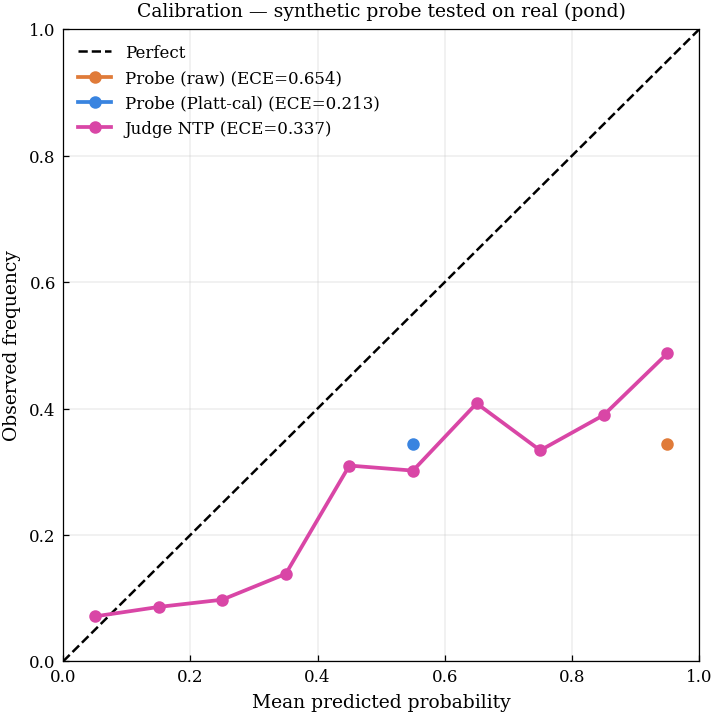

In [59]:
# Calibration curves on real test set
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect')

for probs, label, color in [
    (raw_real,           'Probe (raw)',             '#e07b39'),
    (cal_real,           'Probe (Platt-cal)',        '#3984e0'),
    (real_test_jprobs,   'Judge NTP',               '#d946a6'),
]:
    d     = reliability_diagram_data(probs, y_real)
    valid = ~np.isnan(d['bin_accuracy'])
    ax.plot(d['bin_centers'][valid], d['bin_accuracy'][valid], 'o-',
            color=color, lw=1.8, ms=5, label=f"{label} (ECE={d['ece']:.3f})")

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title(f'Calibration — synthetic probe tested on real ({DATASET})')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
fig.tight_layout()
#fig.savefig(FIGURES_DIR + f'synprobe_calibration_{DATASET}_e-{EXTRACTION_MODEL}_j-{JUDGE_MODEL}.pdf', bbox_inches='tight')

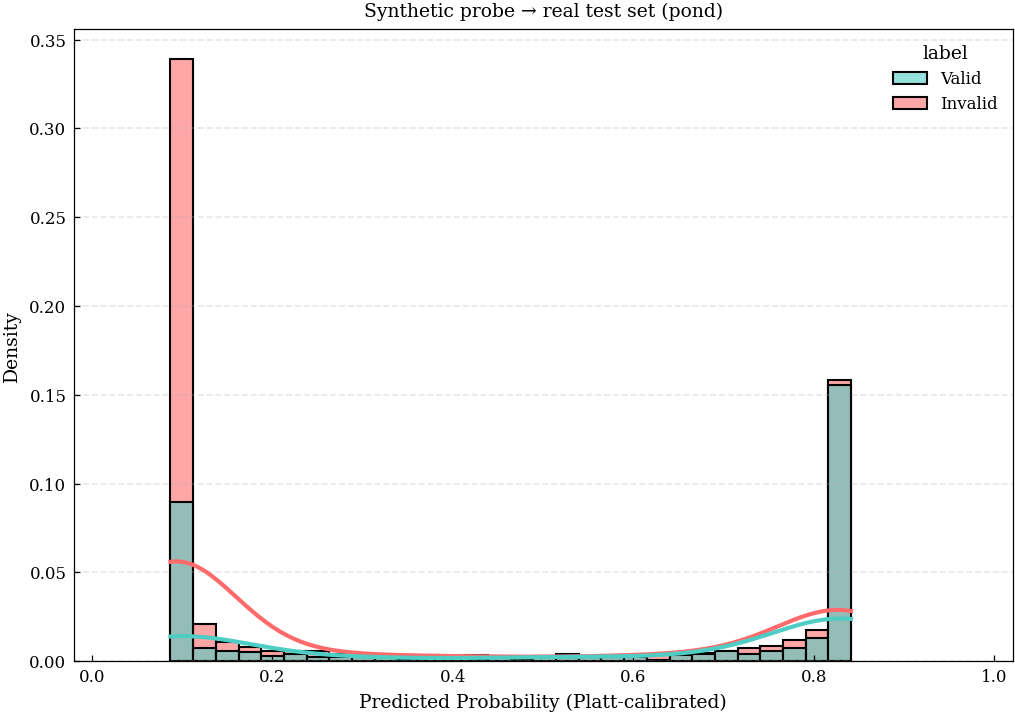

In [27]:
# Probability distributions on real test set
_df_real = pd.DataFrame({'prob': cal_real, 'label': y_real})
_df_real['label'] = _df_real['label'].map({True: 'Valid', False: 'Invalid'})

fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(
    data=_df_real, x='prob', hue='label',
    stat='probability', kde=True, bins=30,
    palette={'Invalid': '#FF6B6B', 'Valid': '#4ECDC4'},
    alpha=0.6, ax=ax, line_kws={'linewidth': 2},
)
ax.set_xlabel('Predicted Probability (Platt-calibrated)')
ax.set_ylabel('Density')
ax.set_title(f'Synthetic probe → real test set ({DATASET})')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xlim(-0.02, 1.02)
fig.tight_layout()
#fig.savefig(FIGURES_DIR + f'synprobe_prob_dist_{DATASET}_e-{EXTRACTION_MODEL}_j-{JUDGE_MODEL}.pdf', bbox_inches='tight')

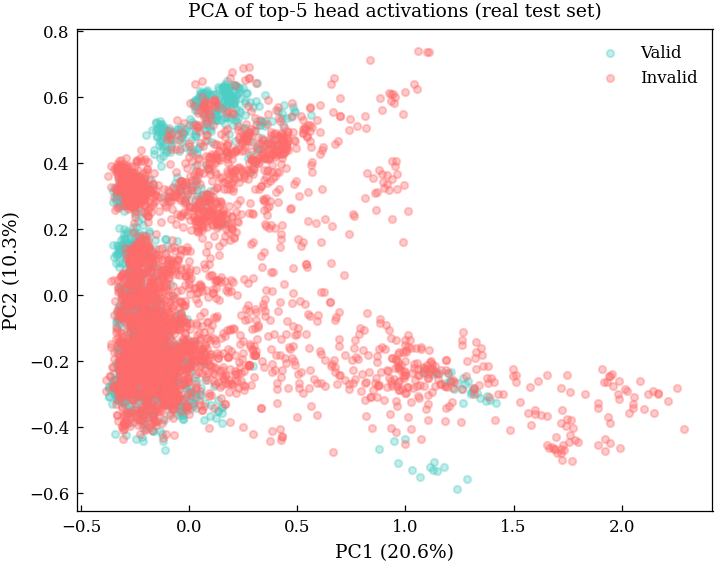

In [28]:
# PCA of top-k head features (real test set, coloured by label)
pca = PCA(n_components=2)
X_real_pca = pca.fit_transform(X_real)

fig, ax = plt.subplots(figsize=(5, 4))
for val, lbl, color in [(True, 'Valid', '#4ECDC4'), (False, 'Invalid', '#FF6B6B')]:
    mask = y_real == val
    ax.scatter(X_real_pca[mask, 0], X_real_pca[mask, 1],
               c=color, alpha=0.35, s=12, label=lbl)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'PCA of top-{TOP_K} head activations (real test set)')
ax.legend()
fig.tight_layout()
#fig.savefig(FIGURES_DIR + f'synprobe_pca_{DATASET}_e-{EXTRACTION_MODEL}_j-{JUDGE_MODEL}.pdf', bbox_inches='tight')

## Breakdown by Modification Type (Synthetic Val Set)

Evaluate how well the probe (trained on synthetic) scores each *type* of
invalid record in the held-out synthetic calibration set.

In [ ]:
# Probe probabilities on synthetic calibration set
raw_cal_probs = final_probe.predict_proba(X_cal)[:, 1]

syn_cal_df = syn_df.iloc[syn_cal_idx].copy()
syn_cal_df['probe_prob'] = raw_cal_probs
syn_cal_df['correct']    = (
    ((raw_cal_probs > 0.5) == syn_labels[syn_cal_idx])
)

print('Per-modification-type accuracy on synthetic cal set:')
print(syn_cal_df.groupby('modification_type')[['correct', 'probe_prob']].agg(
    accuracy=('correct', 'mean'),
    mean_prob=('probe_prob', 'mean'),
    n=('correct', 'count'),
).round(3))

---
## Part II — Layer Output Probe

Repeat the same train → calibrate → test protocol using the full residual-stream
vector at each layer (shape: `n_layers × hidden_size`) instead of individual attention
heads. A probe is scored at every layer via 5-fold CV on the synthetic training pool;
the best layer is selected by F1 and a final probe is trained on the same synthetic
train/cal splits used in Part I.

### Build Layer Feature Matrices

In [ ]:
syn_layer_outputs  = load_synthetic_layer_outputs(DATASET, JUDGE_MODEL, JUDGE_DATE_SYN)
real_layer_outputs = load_layer_outputs(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE, JUDGE_MODEL, JUDGE_DATE_REAL)

_arr0_lo = np.array(syn_layer_outputs[str(syn_measurement_ids[0])], dtype=np.float32)
n_layers_lo, hidden_size = _arr0_lo.shape
print(f'Layer output shape : n_layers={n_layers_lo}, hidden_size={hidden_size}')

print('\nBuilding per-layer feature matrices (synthetic)...')
_all_syn_lo = {str(mid): np.array(syn_layer_outputs[str(mid)], dtype=np.float32)
               for mid in syn_measurement_ids}
layer_datasets_syn: dict[int, np.ndarray] = {
    l: np.stack([_all_syn_lo[str(mid)][l] for mid in syn_measurement_ids], axis=0)
    for l in range(n_layers_lo)
}
del _all_syn_lo
print(f'  Synthetic layer matrix shape : {layer_datasets_syn[0].shape}')

print(f'\nBuilding per-layer feature matrices (real test, {len(real_test_mids)} records)...')
_all_real_lo = {str(mid): np.array(real_layer_outputs[str(mid)], dtype=np.float32)
                for mid in real_test_mids}
layer_datasets_real: dict[int, np.ndarray] = {
    l: np.stack([_all_real_lo[str(mid)][l] for mid in real_test_mids], axis=0)
    for l in range(n_layers_lo)
}
del _all_real_lo
print(f'  Real test layer matrix shape : {layer_datasets_real[0].shape}')

### Layer Selection via Cross-Validation

In [ ]:
layer_scores_f1    = np.zeros(n_layers_lo)
layer_scores_auroc = np.zeros(n_layers_lo)
layer_oof_probs    = {}

print(f'Scoring {n_layers_lo} layers on synthetic CV pool (n={len(syn_cv_idx)})...')
for l in range(n_layers_lo):
    X_cv = layer_datasets_syn[l][syn_cv_idx]
    (_, _, mean_auroc, _, mean_f1, _, _, _, oof_probs) = cv_score(
        probe_template, X_cv, syn_labels_cv, kfold_cv
    )
    layer_scores_f1[l]    = mean_f1
    layer_scores_auroc[l] = mean_auroc
    layer_oof_probs[l]    = oof_probs
    if (l + 1) % 8 == 0:
        print(f'  Layer {l + 1}/{n_layers_lo} done')
print('Done.')

In [ ]:
# F1 by layer line plot — layer output probe
best_layer_lo = int(layer_scores_f1.argmax())
print(f'Best layer : {best_layer_lo}  '
      f'AUROC={layer_scores_auroc[best_layer_lo]:.4f}  '
      f'F1={layer_scores_f1[best_layer_lo]:.4f}')

fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.plot(range(n_layers_lo), layer_scores_f1, 'o-', color='#3984e0', ms=3, label='CV F1')
ax.plot(range(n_layers_lo), layer_scores_auroc, 's--', color='#888888', ms=2.5, lw=0.9, label='CV AUROC')
ax.axvline(best_layer_lo, color='#e07b39', lw=1.0, ls=':',
           label=f'Best: L{best_layer_lo} (F1={layer_scores_f1[best_layer_lo]:.3f})')
ax.set_xlabel('Layer')
ax.set_ylabel('Score')
ax.set_title(f'Layer output probe — CV score by layer ({DATASET}, {JUDGE_MODEL})')
ax.legend(fontsize=7)
ax.set_xlim(-0.5, n_layers_lo - 0.5)
fig.tight_layout()
#fig.savefig(FIGURES_DIR + f'synprobe_layer_f1_by_layer_{DATASET}_j-{JUDGE_MODEL}.pdf', bbox_inches='tight')

### Final Probe: Train on Synthetic, Test on Real

In [ ]:
X_train_lo = layer_datasets_syn[best_layer_lo][syn_train_idx]
X_cal_lo   = layer_datasets_syn[best_layer_lo][syn_cal_idx]
X_real_lo  = layer_datasets_real[best_layer_lo]

y_train_lo = syn_labels[syn_train_idx]
y_cal_lo   = syn_labels[syn_cal_idx]

final_probe_lo = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, class_weight=None, solver='lbfgs',
                               max_iter=1000, random_state=42))
]).fit(X_train_lo, y_train_lo)

raw_cal_lo  = final_probe_lo.predict_proba(X_cal_lo)[:, 1].reshape(-1, 1)
platt_lo    = LogisticRegression(C=1e6, solver='lbfgs', max_iter=1000).fit(raw_cal_lo, y_cal_lo)
raw_real_lo = final_probe_lo.predict_proba(X_real_lo)[:, 1]
cal_real_lo = platt_lo.predict_proba(raw_real_lo.reshape(-1, 1))[:, 1]

print(f'=== Layer {best_layer_lo} output probe — REAL test set ===\n')
lo_raw_metrics = _probe_metrics(raw_real_lo, y_real, f'Layer {best_layer_lo} probe (uncalibrated)')
print()
lo_cal_metrics = _probe_metrics(cal_real_lo, y_real, f'Layer {best_layer_lo} probe (Platt-calibrated)')

In [ ]:
# Calibration curves — layer output probe on real test set
fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.plot([0, 1], [0, 1], 'k--', lw=1.0, label='Perfect')

for probs, label, color in [
    (raw_real_lo,      f'Layer {best_layer_lo} probe (raw)',       '#e07b39'),
    (cal_real_lo,      f'Layer {best_layer_lo} probe (Platt-cal)', '#3984e0'),
    (real_test_jprobs, 'Judge NTP',                                '#d946a6'),
]:
    d     = reliability_diagram_data(probs, y_real)
    valid = ~np.isnan(d['bin_accuracy'])
    ax.plot(d['bin_centers'][valid], d['bin_accuracy'][valid], 'o-',
            color=color, lw=1.4, ms=3.5,
            label=f"{label}\n(ECE={d['ece']:.3f})")

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title(f'Calibration — layer probe, real test set ({DATASET})')
ax.legend(fontsize=7)
ax.grid(alpha=0.2)
fig.tight_layout()
#fig.savefig(FIGURES_DIR + f'synprobe_lo_calibration_{DATASET}_e-{EXTRACTION_MODEL}_j-{JUDGE_MODEL}.pdf', bbox_inches='tight')

In [ ]:
# Probability distributions — layer output probe on real test set
_df_lo = pd.DataFrame({'prob': cal_real_lo, 'label': y_real})
_df_lo['label'] = _df_lo['label'].map({True: 'Valid', False: 'Invalid'})

fig, ax = plt.subplots(figsize=(3.5, 2.8))
sns.histplot(
    data=_df_lo, x='prob', hue='label',
    stat='probability', kde=True, bins=30,
    palette={'Invalid': '#FF6B6B', 'Valid': '#4ECDC4'},
    alpha=0.6, ax=ax, line_kws={'linewidth': 1.4},
)
ax.set_xlabel('Predicted probability (Platt-calibrated)')
ax.set_ylabel('Density')
ax.set_title(f'Layer {best_layer_lo} probe → real test set ({DATASET})')
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.set_xlim(-0.02, 1.02)
fig.tight_layout()
#fig.savefig(FIGURES_DIR + f'synprobe_lo_prob_dist_{DATASET}_e-{EXTRACTION_MODEL}_j-{JUDGE_MODEL}.pdf', bbox_inches='tight')

In [ ]:
# PCA of layer output features (real test set, coloured by label)
pca_lo = PCA(n_components=2)
X_real_lo_pca = pca_lo.fit_transform(X_real_lo)

fig, ax = plt.subplots(figsize=(3.5, 3.0))
for val, lbl, color in [(True, 'Valid', '#4ECDC4'), (False, 'Invalid', '#FF6B6B')]:
    mask = y_real == val
    ax.scatter(X_real_lo_pca[mask, 0], X_real_lo_pca[mask, 1],
               c=color, alpha=0.3, s=8, label=lbl, rasterized=True)
ax.set_xlabel(f'PC1 ({pca_lo.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_lo.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'PCA — layer {best_layer_lo} outputs, real test set ({DATASET})')
ax.legend(markerscale=2)
fig.tight_layout()
#fig.savefig(FIGURES_DIR + f'synprobe_lo_pca_{DATASET}_e-{EXTRACTION_MODEL}_j-{JUDGE_MODEL}.pdf', bbox_inches='tight')

## Summary

In [ ]:
print('=' * 72)
print(f'SYNTHETIC PROBE SUMMARY   dataset={DATASET}   label_mode={LABEL_MODE}')
print(f'  Trained on  : synthetic probe ({len(syn_df)} records, {syn_df["document_id"].nunique()} papers)')
print(f'  Tested on   : real extraction ({len(real_test_idx)} records, '
      f'{real_df.iloc[real_test_idx]["document_id"].nunique()} papers, no overlap)')
print(f'  Judge model : {JUDGE_MODEL}')
print('=' * 72)
print()

jm     = _probe_metrics(real_test_jprobs, y_real, 'Baseline — judge NTP probability')
print()
hm_raw = _probe_metrics(raw_real,    y_real, f'Part I  — head probe (raw)       [{head_labels}]')
print()
hm_cal = _probe_metrics(cal_real,    y_real, f'Part I  — head probe (Platt-cal) [{head_labels}]')
print()
lm_raw = _probe_metrics(raw_real_lo, y_real, f'Part II — layer {best_layer_lo} probe (raw)')
print()
lm_cal = _probe_metrics(cal_real_lo, y_real, f'Part II — layer {best_layer_lo} probe (Platt-cal)')

print()
hdr = f'{"Model":<44} {"Acc":>5}  {"Prec":>5}  {"Rec":>5}  {"F1":>5}  {"AUROC":>5}  {"ECE":>5}  {"BS":>5}  {"BSS":>5}'
print('─' * len(hdr))
print(hdr)
print('─' * len(hdr))
for name, m in [
    ('Judge NTP (uncal)',                                jm),
    (f'Head probe raw  [{head_labels}]',                hm_raw),
    (f'Head probe Platt-cal  [{head_labels}]',          hm_cal),
    (f'Layer {best_layer_lo} probe raw',                lm_raw),
    (f'Layer {best_layer_lo} probe Platt-cal',          lm_cal),
]:
    print(f'{name:<44} {m["acc"]:>5.3f}  {m["prec"]:>5.3f}  {m["rec"]:>5.3f}  '
          f'{m["f1"]:>5.3f}  {m["auroc"]:>5.3f}  {m["ece"]:>5.3f}  '
          f'{m["bs"]:>5.3f}  {m["bss"]:>5.3f}')
print('─' * len(hdr))